# **Modelos lineales jerárquicos**

## *Carga de paquetes y configuración*

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(gt)
})

# Parche para que las tablas gt se vean en Jupyter (mismo del EDA)
repr_html.gt_tbl <- function(obj, ...) gt::as_raw_html(obj)
repr_markdown.gt_tbl <- function(obj, ...) NULL
repr_latex.gt_tbl <- function(obj, ...) NULL
for (g in c("repr_html", "repr_markdown", "repr_latex")) {
  registerS3method(g, "gt_tbl", get(paste0(g, ".gt_tbl")), envir = asNamespace("repr"))
}

# Las rutas de config.R son relativas a la raíz del proyecto.
if (!file.exists("myst.yml") && file.exists("../myst.yml")) setwd("..")

if (file.exists(".Renviron")) readRenviron(".Renviron")

source("R/config.R")
source("R/data_prep.R")
source("R/moderation_pipeline.R")
source("R/cross_validation.R")
source("R/elastic_net.R")

getwd()

[1] "/workspaces/social-support-entrapment-gender-atlantico"

### *Configuración*

In [2]:
tribble(
  ~Decisión,                     ~Valor,
  "Variable respuesta",          OUTCOME_VAR,
  "Dimensiones de apoyo",        paste(SUPPORT_VARS, collapse = ", "),
  "Moderador",                   sprintf("%s → %s", GENDER_VAR, GENDER_TERM),
  "Codificación de género",      sprintf("%s (%s)", GENDER_CODING,
                                         paste(sprintf("%s = %s",
                                               names(GENDER_CODING_SCHEMES[[GENDER_CODING]]),
                                               GENDER_CODING_SCHEMES[[GENDER_CODING]]),
                                               collapse = ", ")),
  "Covariables",                 paste(COVARIATE_VARS, collapse = ", "),
  "Colapso de SSE",              paste(sprintf("%s → %s", names(SSE_COLLAPSE_MAP),
                                               SSE_COLLAPSE_MAP), collapse = " | "),
  "Niveles de referencia",       paste(sprintf("%s = %s", names(REFERENCE_LEVELS),
                                               unlist(REFERENCE_LEVELS)), collapse = " | "),
  "Tratamiento de faltantes",    "listwise (sin imputación)",
  "N esperado",                  as.character(EXPECTED_N),
  "Winsorización de extremos",   ifelse(WINSORIZE_EXTREMES, "sí", "no"),
  "Semilla",                     as.character(SEED)
) %>%
  gt() %>%
  tab_header(title = "Configuración del pipeline",
             subtitle = "Definida en R/config.R")

<div id="jbrwbuujih" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#jbrwbuujih table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#jbrwbuujih thead, #jbrwbuujih tbody, #jbrwbuujih tfoot, #jbrwbuujih tr, #jbrwbuujih td, #jbrwbuujih th {
  border-style: none;
}

#jbrwbuujih p {
  margin: 0;
  padding: 0;
}

#jbrwbuujih .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#jbrwbuujih .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#jbrwbuujih .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#jbrwbuujih .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#jbrwbuujih .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#jbrwbuujih .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#jbrwbuujih .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#jbrwbuujih .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#jbrwbuujih .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#jbrwbuujih .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#jbrwbuujih .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#jbrwbuujih .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#jbrwbuujih .gt_spanner_row {
  border-bottom-style: hidden;
}

#jbrwbuujih .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

## *Preparación de los datos*

`run_data_prep()`, definida en `R/data_prep.R`, recodifica los `Missing` a
`NA`, colapsa SSE a `Low / Medium-High`, aplica *listwise deletion* sobre las
variables del modelo, fija los niveles de referencia, centra las tres
dimensiones de apoyo por su gran media y codifica el género. Se detiene con
error si el N no coincide con `EXPECTED_N`. No se eliminan ni winsorizan valores extremos

El resultado se guarda en `data/df_modeling_2026.csv`

In [3]:
model_data <- run_data_prep()

Filas crudas:          680
Muestra analitica:     530 (listwise sobre Entrapment, Family, Friends, SigOthers, Gender, Municipality, SSE, Ethnicity)
Niveles de referencia: SSE = Low | Ethnicity = Mestizo | Municipality = Polo Nuevo
Grandes medias:        Family = 0.030437 | Friends = 0.032544 | SigOthers = 0.045578
Codificacion genero:   dummy (Female = 0, Male = 1)
Escrito: data/df_modeling_2026.csv


In [4]:
glimpse(model_data)

Rows: 530
Columns: 13
$ Entrapment    <dbl> 1.03400222, -0.22683442, 0.41735813, -0.67182740, -0.812…
$ Family        <dbl> -1.52555119, 0.95460349, 0.44104301, -0.44581134, 1.0442…
$ Friends       <dbl> -1.42787043, 1.20533719, 0.93064687, -0.14284219, 0.2973…
$ SigOthers     <dbl> -1.0856793, 0.8657182, -0.1872779, 0.8153423, -0.7443235…
$ Gender        <fct> Female, Female, Female, Male, Male, Female, Male, Female…
$ Municipality  <fct> Polo Nuevo, Polo Nuevo, Polo Nuevo, Polo Nuevo, Polo Nue…
$ SSE           <fct> Low, Low, Low, Low, Low, Low, Low, Low, Low, Low, Low, L…
$ Ethnicity     <fct> Afrodescendant, Afrodescendant, Afrodescendant, Mestizo,…
$ Entrapment_SE <dbl> 0.3209509, 0.3074096, 0.3213874, 0.3863064, 0.3861574, 0…
$ Family_c      <dbl> -1.55598821, 0.92416647, 0.41060599, -0.47624836, 1.0138…
$ Friends_c     <dbl> -1.46041479, 1.17279283, 0.89810251, -0.17538655, 0.2647…
$ SigOthers_c   <dbl> -1.1312571, 0.8201405, -0.2328557, 0.7697645, -0.7899012…
$ Gender_code   <d

### *Composición de la muestra analítica*

El nivel de referencia de cada factor va marcado con `(ref)`.

In [5]:
map_dfr(CATEGORICAL_VARS, function(v) {
  ref <- levels(model_data[[v]])[1]
  model_data %>%
    count(Nivel = .data[[v]], name = "n") %>%
    mutate(Variable = v,
           Nivel = ifelse(as.character(Nivel) == ref,
                          paste0(as.character(Nivel), " (ref)"),
                          as.character(Nivel)),
           `%` = round(100 * n / sum(n), 1))
}) %>%
  select(Variable, Nivel, n, `%`) %>%
  gt(groupname_col = "Variable") %>%
  tab_header(title = sprintf("Muestra analítica (N = %d)", nrow(model_data)))

<div id="yafmoldpel" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#yafmoldpel table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#yafmoldpel thead, #yafmoldpel tbody, #yafmoldpel tfoot, #yafmoldpel tr, #yafmoldpel td, #yafmoldpel th {
  border-style: none;
}

#yafmoldpel p {
  margin: 0;
  padding: 0;
}

#yafmoldpel .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#yafmoldpel .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#yafmoldpel .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#yafmoldpel .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#yafmoldpel .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#yafmoldpel .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#yafmoldpel .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#yafmoldpel .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#yafmoldpel .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#yafmoldpel .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#yafmoldpel .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#yafmoldpel .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#yafmoldpel .gt_spanner_row {
  border-bottom-style: hidden;
}

#yafmoldpel .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

## *Fórmulas*

Las 10 fórmulas se construyen de la siguiente manera:

- **M0**: solo intercepto.
- **M1**: género + covariables.
- **M2_D / M3_D**: para cada dimensión *D*, efecto principal y luego la
  interacción *D* × género.
- **M2_joint / M3_joint**: las tres dimensiones a la vez, y sus tres
  interacciones.

In [6]:
formulas <- build_formulas()

tibble(
  Modelo  = names(formulas),
  Fórmula = map_chr(formulas, formula_text)
) %>%
  gt() %>%
  tab_header(title = sprintf("Secuencia jerárquica (%d modelos)", length(formulas)))

<div id="rbelxepclc" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#rbelxepclc table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#rbelxepclc thead, #rbelxepclc tbody, #rbelxepclc tfoot, #rbelxepclc tr, #rbelxepclc td, #rbelxepclc th {
  border-style: none;
}

#rbelxepclc p {
  margin: 0;
  padding: 0;
}

#rbelxepclc .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#rbelxepclc .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#rbelxepclc .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#rbelxepclc .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#rbelxepclc .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#rbelxepclc .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#rbelxepclc .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#rbelxepclc .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#rbelxepclc .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#rbelxepclc .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#rbelxepclc .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#rbelxepclc .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#rbelxepclc .gt_spanner_row {
  border-bottom-style: hidden;
}

#rbelxepclc .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

## *Ajuste*

Los 10 modelos se estiman con `lm()` donde todos usan exactamente las mismas observaciones.

In [7]:
models <- fit_models(formulas = formulas, data = model_data)

cat(sprintf("Modelos ajustados: %d\n", length(models)))
cat(sprintf("N por modelo:      %s\n",
            paste(unique(map_int(models, ~ length(.x$residuals))), collapse = ", ")))
names(models)

Modelos ajustados: 10
N por modelo:      530


[1] "M0"           "M1"           "M2_Family"    "M3_Family"    "M2_Friends"  
 [6] "M3_Friends"   "M2_SigOthers" "M3_SigOthers" "M2_joint"     "M3_joint"

## *Tabla resumen*

In [8]:
models_summary <- summarise_models(models)

models_summary %>%
  gt() %>%
  fmt_number(c(r_squared, adj_r_squared), decimals = 4) %>%
  cols_label(model = "Modelo", formula = "Fórmula", n = "N",
             df_residual = "gl residuales",
             r_squared = "R²", adj_r_squared = "R² ajustado") %>%
  tab_header(title = "Resumen de los modelos ajustados")

<div id="yafmoldpel" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#yafmoldpel table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#yafmoldpel thead, #yafmoldpel tbody, #yafmoldpel tfoot, #yafmoldpel tr, #yafmoldpel td, #yafmoldpel th {
  border-style: none;
}

#yafmoldpel p {
  margin: 0;
  padding: 0;
}

#yafmoldpel .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#yafmoldpel .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#yafmoldpel .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#yafmoldpel .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#yafmoldpel .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#yafmoldpel .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#yafmoldpel .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#yafmoldpel .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#yafmoldpel .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#yafmoldpel .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#yafmoldpel .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#yafmoldpel .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#yafmoldpel .gt_spanner_row {
  border-bottom-style: hidden;
}

#yafmoldpel .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

## *Coeficientes (EE OLS)*

In [9]:
coefficients_ols <- tidy_coefficients(models)

cat(sprintf("Filas en la tabla de coeficientes: %d\n", nrow(coefficients_ols)))

coefficients_ols %>%
  gt() %>%
  fmt_number(c(estimate, std_error, statistic), decimals = 4) %>%
  fmt(columns = p_value,
      fns = function(x) ifelse(x < 0.001, "< .001", sprintf("%.3f", x))) %>%
  cols_label(model = "Modelo", term = "Término", estimate = "b",
             std_error = "EE", statistic = "t", p_value = "p") %>%
  tab_header(title = "Coeficientes de los 10 modelos",
             subtitle = "Errores estándar OLS")

Filas en la tabla de coeficientes: 100


<div id="rbelxepclc" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#rbelxepclc table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#rbelxepclc thead, #rbelxepclc tbody, #rbelxepclc tfoot, #rbelxepclc tr, #rbelxepclc td, #rbelxepclc th {
  border-style: none;
}

#rbelxepclc p {
  margin: 0;
  padding: 0;
}

#rbelxepclc .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#rbelxepclc .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#rbelxepclc .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#rbelxepclc .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#rbelxepclc .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#rbelxepclc .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#rbelxepclc .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#rbelxepclc .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#rbelxepclc .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#rbelxepclc .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#rbelxepclc .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#rbelxepclc .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#rbelxepclc .gt_spanner_row {
  border-bottom-style: hidden;
}

#rbelxepclc .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Vistazo a los términos de interacción de los modelos M3:

In [10]:
coefficients_ols %>%
  filter(str_detect(model, "^M3"), str_detect(term, ":")) %>%
  gt() %>%
  fmt_number(c(estimate, std_error, statistic), decimals = 4) %>%
  fmt(columns = p_value,
      fns = function(x) ifelse(x < 0.001, "< .001", sprintf("%.3f", x))) %>%
  cols_label(model = "Modelo", term = "Término", estimate = "b",
             std_error = "EE", statistic = "t", p_value = "p") %>%
  tab_header(title = "Términos Dimensión × Género")

<div id="imripgreek" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#imripgreek table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#imripgreek thead, #imripgreek tbody, #imripgreek tfoot, #imripgreek tr, #imripgreek td, #imripgreek th {
  border-style: none;
}

#imripgreek p {
  margin: 0;
  padding: 0;
}

#imripgreek .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#imripgreek .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#imripgreek .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#imripgreek .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#imripgreek .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#imripgreek .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#imripgreek .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#imripgreek .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#imripgreek .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#imripgreek .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#imripgreek .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#imripgreek .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#imripgreek .gt_spanner_row {
  border-bottom-style: hidden;
}

#imripgreek .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

## *Guardado*

- `outputs/models/fitted_models.rds` — lista nombrada con los 10 objetos `lm`.
- `outputs/models/fit_manifest.json` — cómo se modeló (codificación de género,
  grandes medias, niveles de referencia).
- `outputs/tables/models_summary.csv`
- `outputs/tables/coefficients_ols.csv`

In [11]:
fit_manifest <- build_fit_manifest(models, model_data, coding = GENDER_CODING)

saved <- save_model_outputs(models, models_summary, coefficients_ols, fit_manifest)

cat(paste(saved, collapse = "\n"), "\n")

outputs/models/fitted_models.rds
outputs/tables/models_summary.csv
outputs/tables/coefficients_ols.csv
outputs/models/fit_manifest.json 


## *Elastic net (modelo 11)*

Además de los 10 modelos jerárquicos se ajusta un modelo de elastic net. En
lugar de fijar de antemano qué términos entran, parte de todos los términos
candidatos (los de M3_joint) y una penalización encoge los coeficientes,
dejando en cero los que no aportan a la predicción. Todas las columnas se
penalizan por igual: género, covariables, dimensiones de apoyo e
interacciones.

Elastic net tiene dos hiperparámetros que se eligen con los datos:

- **α** mezcla las penalizaciones lasso. Se prueban 0.1, 0.25, 0.5, 0.75 y 1.
- **λ** es la fuerza de la penalización: con λ grande quedan pocas columnas.

Se eligen con una **validación cruzada interna** de 10 folds sobre los mismos
530 casos, estratificada por género y con el preprocesamiento aprendido en
cada fold, y la **regla de 1 EE**: entre las combinaciones (α, λ) cuyo RMSE no
se distingue del mínimo, la que deja menos columnas distintas de cero. Con el
α y λ elegidos se ajusta el modelo final con los 530 casos, el equivalente de
los `lm()` de arriba. α no se fija de antemano: se elige junto con λ entre los
cinco valores de la grilla.

In [12]:
clean_data <- build_clean_sample()

set.seed(SEED)
en_model <- tune_en(clean_data)

cat(sprintf("α elegido:                %g\n", en_model$alpha))
cat(sprintf("λ elegido:                %.4f\n", en_model$lambda))
cat(sprintf("Umbral interno (1 EE):    %.4f\n", en_model$threshold))
cat(sprintf("Columnas distintas de 0:  %d de %d\n", length(en_model$selected), length(en_model$columns)))
cat(sprintf("R² dentro de muestra:     %.4f\n", en_r_squared(en_model, clean_data)))

α elegido:                1
λ elegido:                0.0689
Umbral interno (1 EE):    0.8907
Columnas distintas de 0:  3 de 14
R² dentro de muestra:     0.1971


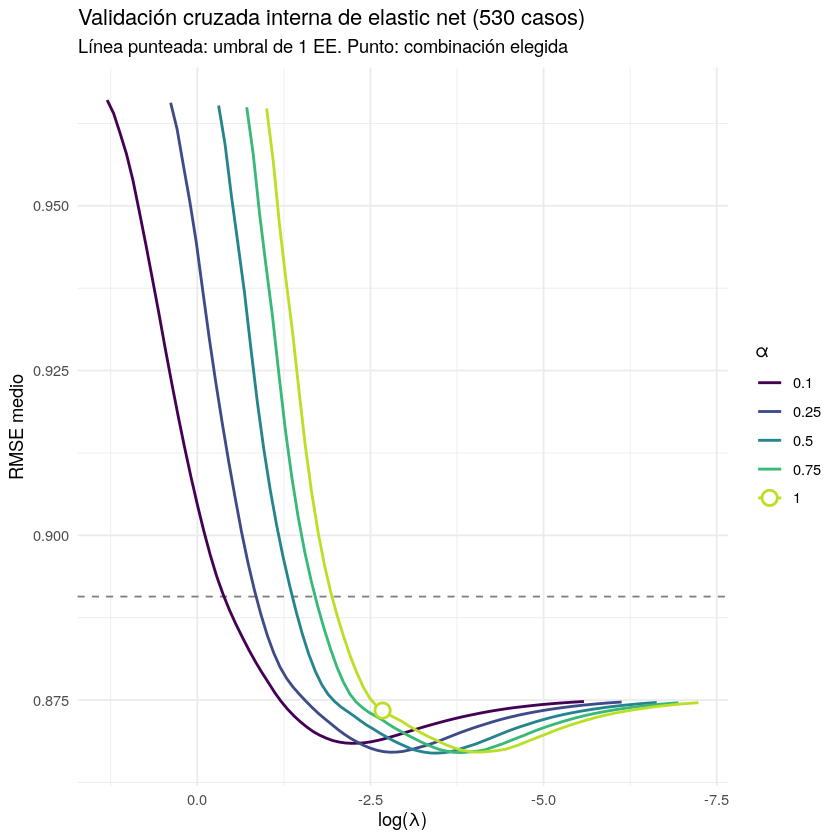

In [13]:
eleccion <- en_model$inner_cv %>% filter(alpha == en_model$alpha, lambda == en_model$lambda)

en_model$inner_cv %>%
  mutate(alpha = factor(alpha)) %>%
  ggplot(aes(x = log(lambda), y = rmse_mean, color = alpha)) +
  geom_hline(yintercept = en_model$threshold, linetype = "dashed", color = "grey50") +
  geom_line(linewidth = 0.8) +
  geom_point(data = eleccion %>% mutate(alpha = factor(alpha)),
             size = 3.5, shape = 21, fill = "white", stroke = 1.2) +
  scale_x_reverse() +
  scale_color_viridis_d(end = 0.9) +
  labs(title = "Validación cruzada interna de elastic net (530 casos)",
       subtitle = "Línea punteada: umbral de 1 EE. Punto: combinación elegida",
       x = "log(λ)", y = "RMSE medio", color = "α") +
  theme_minimal()

In [14]:
en_coefficients(en_model) %>%
  mutate(lm_M2_Family = coef(models$M2_Family)[term],
         lm_M2_joint  = coef(models$M2_joint)[term]) %>%
  gt() %>%
  fmt_number(-term, decimals = 4) %>%
  sub_missing(missing_text = "—") %>%
  cols_label(term = "Columna", estimate = "Elastic net",
             lm_M2_Family = "M2_Family", lm_M2_joint = "M2_joint") %>%
  tab_spanner("lm()", c(lm_M2_Family, lm_M2_joint)) %>%
  tab_style(style = cell_text(color = "grey60"),
            locations = cells_body(columns = estimate, rows = estimate == 0)) %>%
  tab_header(title = "Coeficientes del modelo final de elastic net",
             subtitle = sprintf("α = %g, λ = %.4f", en_model$alpha, en_model$lambda))

<div id="nskdlujivt" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#nskdlujivt table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#nskdlujivt thead, #nskdlujivt tbody, #nskdlujivt tfoot, #nskdlujivt tr, #nskdlujivt td, #nskdlujivt th {
  border-style: none;
}

#nskdlujivt p {
  margin: 0;
  padding: 0;
}

#nskdlujivt .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#nskdlujivt .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#nskdlujivt .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#nskdlujivt .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#nskdlujivt .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#nskdlujivt .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#nskdlujivt .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#nskdlujivt .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#nskdlujivt .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#nskdlujivt .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#nskdlujivt .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#nskdlujivt .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#nskdlujivt .gt_spanner_row {
  border-bottom-style: hidden;
}

#nskdlujivt .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Las columnas que deja elastic net se comparan con las de cada modelo
jerárquico: la selección puede ser **igual** a un modelo, un **subconjunto**
de alguno (todas sus columnas están en el modelo, aunque el modelo tenga
otras más) o **ninguno**.

In [15]:
match_hierarchical(en_model$selected, model_data) %>%
  locate_hierarchical() %>%
  gt() %>%
  sub_values(values = "", replacement = "—") %>%
  cols_label(relation = "Relación", model = "Modelo más pequeño que la contiene",
             contained_in = "Todos los modelos que la contienen",
             left_out = "Columnas de ese modelo que elastic net deja fuera") %>%
  tab_header(title = "Ubicación de elastic net respecto a los modelos jerárquicos")

<div id="uerbosnpxv" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#uerbosnpxv table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#uerbosnpxv thead, #uerbosnpxv tbody, #uerbosnpxv tfoot, #uerbosnpxv tr, #uerbosnpxv td, #uerbosnpxv th {
  border-style: none;
}

#uerbosnpxv p {
  margin: 0;
  padding: 0;
}

#uerbosnpxv .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#uerbosnpxv .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#uerbosnpxv .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#uerbosnpxv .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#uerbosnpxv .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#uerbosnpxv .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#uerbosnpxv .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#uerbosnpxv .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#uerbosnpxv .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#uerbosnpxv .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#uerbosnpxv .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#uerbosnpxv .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#uerbosnpxv .gt_spanner_row {
  border-bottom-style: hidden;
}

#uerbosnpxv .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

In [16]:
cat(sprintf("Guardado: %s\n", save_en_model(en_model)))

Guardado: outputs/models/en_model.rds


## *Validación cruzada*

Además del ajuste con la muestra completa, se estima qué tan bien predice
cada uno de los 11 modelos a estudiantes que no se usaron para ajustarlo. 

- **10 folds × 20 repeticiones** (200 particiones), estratificadas por género.
  Los 11 modelos se evalúan sobre exactamente las mismas particiones.
- **Preprocesamiento por fold** 
- **Elastic net repite el procedimiento completo en cada partición:** 
- **Métricas por fold:** RMSE, MAE y R² fuera de muestra (1 − SSE / SST, con
  la media del entrenamiento como predicción de referencia).

In [17]:
folds <- make_cv_folds(clean_data)

folds %>%
  mutate(female = clean_data[[CV_STRATA_VAR]][row_id] == "Female") %>%
  group_by(repeat_id, fold) %>%
  summarise(n = n(), pct_female = 100 * mean(female), .groups = "drop") %>%
  summarise(
    Particiones           = n(),
    `Tamaño mínimo`       = min(n),
    `Tamaño máximo`       = max(n),
    `% mujeres (mínimo)`  = min(pct_female),
    `% mujeres (máximo)`  = max(pct_female)
  ) %>%
  mutate(`% mujeres (muestra)` = 100 * mean(clean_data[[CV_STRATA_VAR]] == "Female")) %>%
  gt() %>%
  fmt_number(starts_with("%"), decimals = 1) %>%
  tab_header(title = "Tamaño y composición por género de los folds de prueba",
             subtitle = sprintf("%d folds × %d repeticiones", CV_FOLDS, CV_REPEATS))

<div id="dcafzxdmgu" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#dcafzxdmgu table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#dcafzxdmgu thead, #dcafzxdmgu tbody, #dcafzxdmgu tfoot, #dcafzxdmgu tr, #dcafzxdmgu td, #dcafzxdmgu th {
  border-style: none;
}

#dcafzxdmgu p {
  margin: 0;
  padding: 0;
}

#dcafzxdmgu .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#dcafzxdmgu .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#dcafzxdmgu .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#dcafzxdmgu .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#dcafzxdmgu .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#dcafzxdmgu .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#dcafzxdmgu .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#dcafzxdmgu .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#dcafzxdmgu .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#dcafzxdmgu .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#dcafzxdmgu .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#dcafzxdmgu .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#dcafzxdmgu .gt_spanner_row {
  border-bottom-style: hidden;
}

#dcafzxdmgu .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

In [18]:
cv_results <- run_repeated_cv(clean_data, folds, formulas = formulas)

cat(sprintf("Filas (partición × modelo): %d\n", nrow(cv_results)))
cat(sprintf("Guardado: %s\n", save_cv_results(cv_results)))

Filas (partición × modelo): 2200
Guardado: outputs/tables/cv_fold_metrics.csv
